In [1]:
# Affichage des environnements
from GridWorld import GridWorld
from ClassificationEnv import ClassificationEnv

gw = GridWorld()
print(gw)

# Pour ClassificationEnv, il faut charger X/y
import numpy as np
X = np.load('X_200000.npy')
y = np.load('y_200000.npy')
cl_env = ClassificationEnv(X, y)
print(cl_env)

In [2]:
# Affichage des architectures de modèles
from DQN import DQN
from CNN import CNN
from DQNClassifier import DQNClassifier

print(DQN)
print(CNN)
print(DQNClassifier)

<class 'DQN.DQN'>
<class 'CNN.CNN'>
<class 'DQNClassifier.DQNClassifier'>


## 4. Préparation et vérification des données

Chargement des jeux de données, vérification de l'intégrité et visualisation de la distribution des classes.

X shape: (200000, 3, 10, 10), y shape: (200000,)


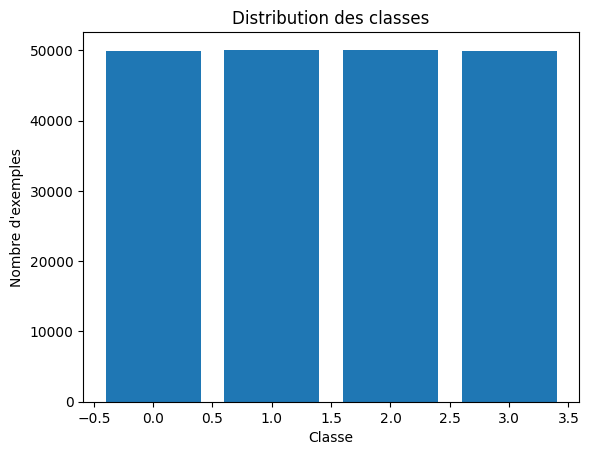

In [4]:
# Chargement et vérification des données
import numpy as np
import matplotlib.pyplot as plt


print(f"X shape: {X.shape}, y shape: {y.shape}")

# Distribution des classes
def plot_class_distribution(y):
    classes, counts = np.unique(y, return_counts=True)
    plt.bar(classes, counts)
    plt.xlabel('Classe')
    plt.ylabel('Nombre d\'exemples')
    plt.title('Distribution des classes')
    plt.show()

plot_class_distribution(y)

In [30]:
! python check_database.py

Shape X: (20000, 3, 10, 10)
Shape y: (20000,)
Doublons sur X uniquement : 0
Doublons sur (X, y) : 0
Répartition des classes :
  Classe 0: 4917
  Classe 1: 4991
  Classe 2: 4999
  Classe 3: 5093


## 5. Expériences DQN sur GridWorld

Lancement de l'entraînement DQN sur GridWorld, analyse des logs, visualisation des récompenses et des trajectoires.

In [22]:
# Exécution du script d'entraînement DQN (affiche les logs comme dans le terminal)
!python trainDQN.py

INFO:root:Utilisation du GPU MPS (Apple Silicon)
INFO:root:Episode 10, Reward: -8.20, Epsilon: 1.000, Success Rate: 0.100, Loss: 0.0070, Steps: 16
INFO:root:Episode 20, Reward: -2.10, Epsilon: 0.999, Success Rate: 0.100, Loss: 0.0061, Steps: 5
INFO:root:Episode 30, Reward: -11.40, Epsilon: 0.999, Success Rate: 0.133, Loss: 0.0127, Steps: 22
INFO:root:Episode 40, Reward: -1.55, Epsilon: 0.999, Success Rate: 0.175, Loss: 0.0134, Steps: 3
INFO:root:Episode 50, Reward: -3.10, Epsilon: 0.998, Success Rate: 0.200, Loss: 0.0152, Steps: 9
INFO:root:Episode 60, Reward: -55.95, Epsilon: 0.998, Success Rate: 0.200, Loss: 0.0160, Steps: 112
INFO:root:Episode 70, Reward: -1.25, Epsilon: 0.998, Success Rate: 0.186, Loss: 0.0113, Steps: 2
INFO:root:Episode 80, Reward: -34.10, Epsilon: 0.997, Success Rate: 0.188, Loss: 0.0145, Steps: 74
INFO:root:Episode 90, Reward: -35.90, Epsilon: 0.997, Success Rate: 0.167, Loss: 0.0337, Steps: 63
INFO:root:Episode 100, Reward: -10.40, Epsilon: 0.997, Success Rate:

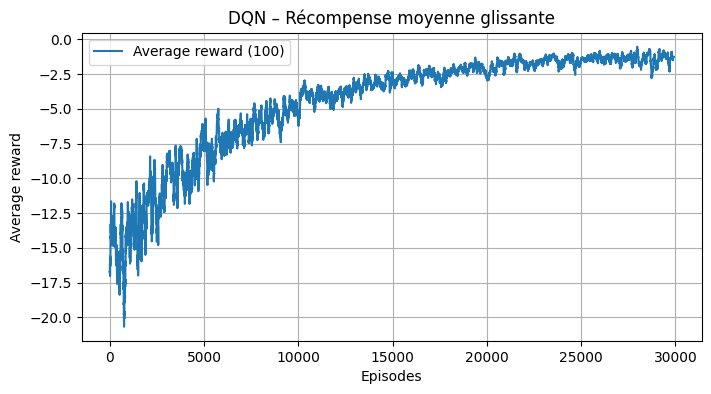

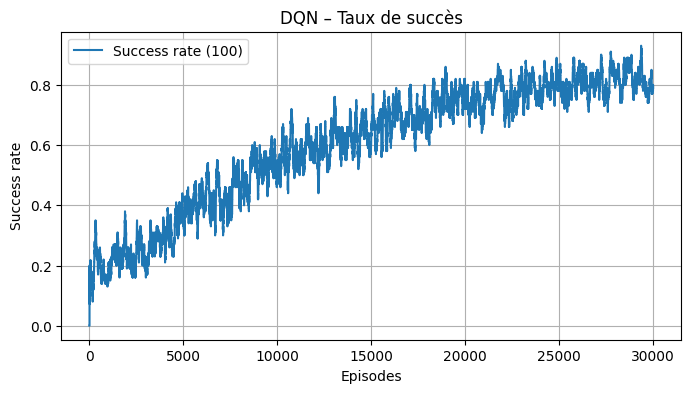

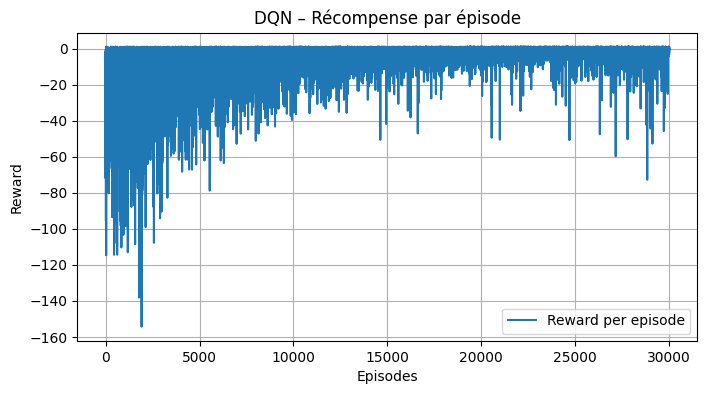

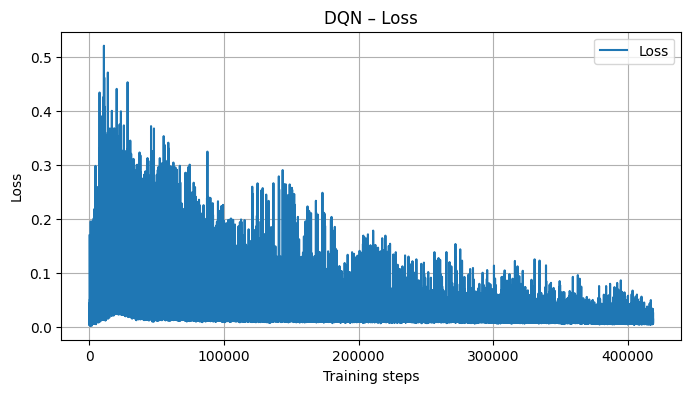

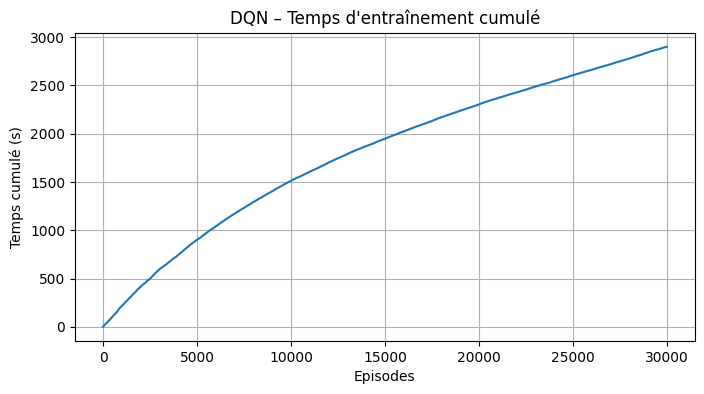

In [25]:
# Affichage des courbes DQN (avg reward, success, reward, loss, temps)
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = os.path.join('results', '03')

# Average reward (glissante)
avg_rewards = np.load(os.path.join(base_path, 'dqn_avg_rewards.npy'))
plt.figure(figsize=(8,4))
plt.plot(avg_rewards, label='Average reward (100)')
plt.xlabel('Episodes')
plt.ylabel('Average reward')
plt.title('DQN – Récompense moyenne glissante')
plt.legend()
plt.grid(True)
plt.show()

# Success rate
success_rates = np.load(os.path.join(base_path, 'dqn_success_rates.npy'))
plt.figure(figsize=(8,4))
plt.plot(success_rates, label='Success rate (100)')
plt.xlabel('Episodes')
plt.ylabel('Success rate')
plt.title('DQN – Taux de succès')
plt.legend()
plt.grid(True)
plt.show()

# Reward par épisode
rewards = np.load(os.path.join(base_path, 'dqn_episode_rewards.npy'))
plt.figure(figsize=(8,4))
plt.plot(rewards, label='Reward per episode')
plt.xlabel('Episodes')
plt.ylabel('Reward')
plt.title('DQN – Récompense par épisode')
plt.legend()
plt.grid(True)
plt.show()

# Loss
losses = np.load(os.path.join(base_path, 'dqn_losses.npy'))
plt.figure(figsize=(8,4))
plt.plot(losses, label='Loss')
plt.xlabel('Training steps')
plt.ylabel('Loss')
plt.title('DQN – Loss')
plt.legend()
plt.grid(True)
plt.show()

# Temps d'entraînement cumulé
training_times = np.load(os.path.join(base_path, 'dqn_training_times.npy'))
plt.figure(figsize=(8,4))
plt.plot(training_times)
plt.xlabel('Episodes')
plt.ylabel('Temps cumulé (s)')
plt.title("DQN – Temps d'entraînement cumulé")
plt.grid(True)
plt.show()

## Test du DQN (évaluation sur 1000 épisodes)

Les courbes suivantes présentent les performances du modèle DQN entraîné, évalué sur 1000 épisodes dans GridWorld.

In [23]:
# Lancer le test du DQN et sauvegarder les courbes
!python testDQN.py

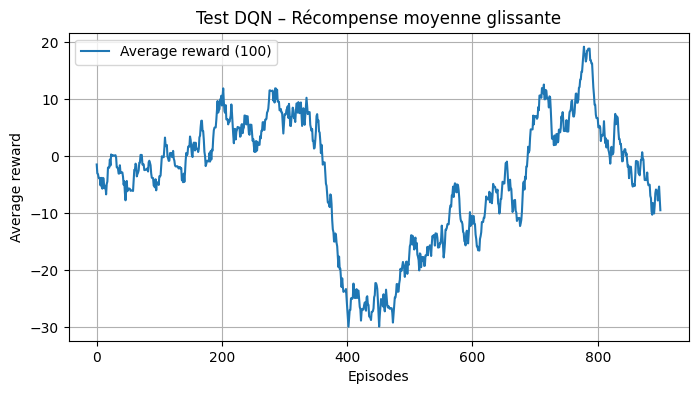

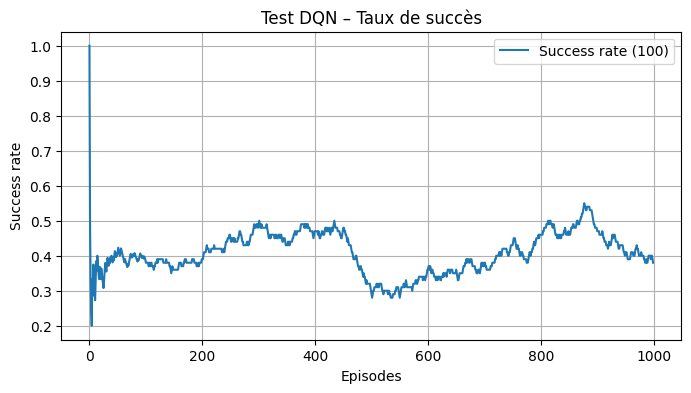

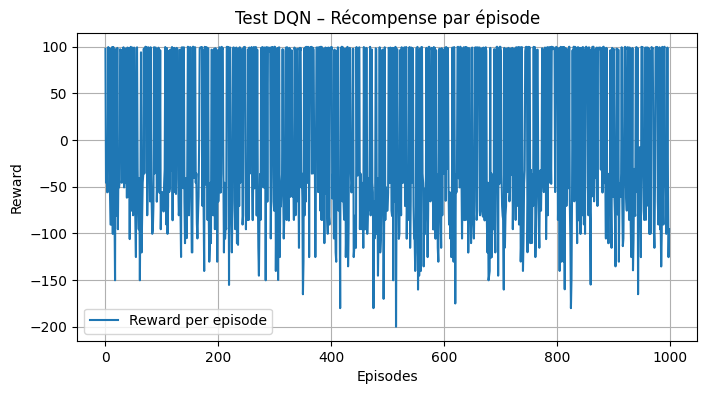

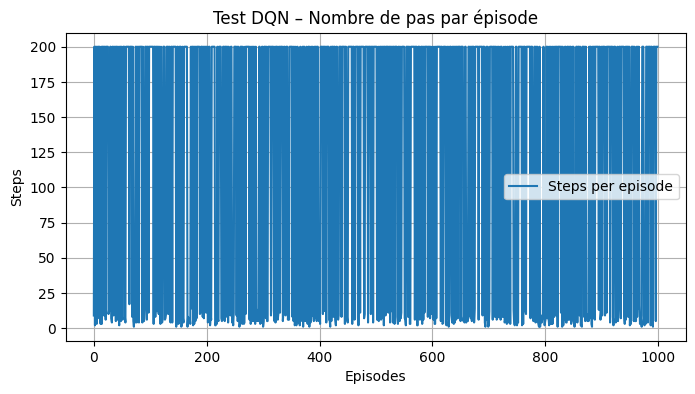

In [26]:
# Affichage des courbes de test DQN
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = os.path.join('results', '03')

# Average reward (glissante)
avg_rewards = np.load(os.path.join(base_path, 'testdqn_avg_rewards.npy'))
plt.figure(figsize=(8,4))
plt.plot(avg_rewards, label='Average reward (100)')
plt.xlabel('Episodes')
plt.ylabel('Average reward')
plt.title('Test DQN – Récompense moyenne glissante')
plt.legend()
plt.grid(True)
plt.show()

# Success rate
success_rates = np.load(os.path.join(base_path, 'testdqn_success_rates.npy'))
plt.figure(figsize=(8,4))
plt.plot(success_rates, label='Success rate (100)')
plt.xlabel('Episodes')
plt.ylabel('Success rate')
plt.title('Test DQN – Taux de succès')
plt.legend()
plt.grid(True)
plt.show()

# Reward par épisode
rewards = np.load(os.path.join(base_path, 'testdqn_episode_rewards.npy'))
plt.figure(figsize=(8,4))
plt.plot(rewards, label='Reward per episode')
plt.xlabel('Episodes')
plt.ylabel('Reward')
plt.title('Test DQN – Récompense par épisode')
plt.legend()
plt.grid(True)
plt.show()

# Steps per episode
steps = np.load(os.path.join(base_path, 'testdqn_steps_per_episode.npy'))
plt.figure(figsize=(8,4))
plt.plot(steps, label='Steps per episode')
plt.xlabel('Episodes')
plt.ylabel('Steps')
plt.title('Test DQN – Nombre de pas par épisode')
plt.legend()
plt.grid(True)
plt.show()

## 6. Expériences CNN sur la classification

Entraînement du CNN sur le jeu de données, affichage des courbes de loss et d'accuracy, analyse des performances.

In [5]:
# Exécution du script d'entraînement CNN (affiche les logs comme dans le terminal)
!python trainCNN.py

INFO:root:Utilisation du GPU MPS (Apple Silicon)
INFO:root:Epoch 0 | Train loss: 0.7272, Train acc: 0.586 | Test loss: 0.6237, Test acc: 0.615
INFO:root:Epoch 1 | Train loss: 0.6027, Train acc: 0.627 | Test loss: 0.5834, Test acc: 0.626
INFO:root:Epoch 2 | Train loss: 0.5742, Train acc: 0.633 | Test loss: 0.5716, Test acc: 0.630
INFO:root:Epoch 3 | Train loss: 0.5647, Train acc: 0.635 | Test loss: 0.5682, Test acc: 0.632
INFO:root:Epoch 4 | Train loss: 0.5574, Train acc: 0.638 | Test loss: 0.5612, Test acc: 0.631
INFO:root:Epoch 5 | Train loss: 0.5528, Train acc: 0.637 | Test loss: 0.5579, Test acc: 0.636
INFO:root:Epoch 6 | Train loss: 0.5489, Train acc: 0.639 | Test loss: 0.5601, Test acc: 0.632
INFO:root:Epoch 7 | Train loss: 0.5458, Train acc: 0.638 | Test loss: 0.5654, Test acc: 0.635
INFO:root:Epoch 8 | Train loss: 0.5425, Train acc: 0.639 | Test loss: 0.5591, Test acc: 0.632
INFO:root:Epoch 9 | Train loss: 0.5396, Train acc: 0.641 | Test loss: 0.5563, Test acc: 0.637
INFO:root:E

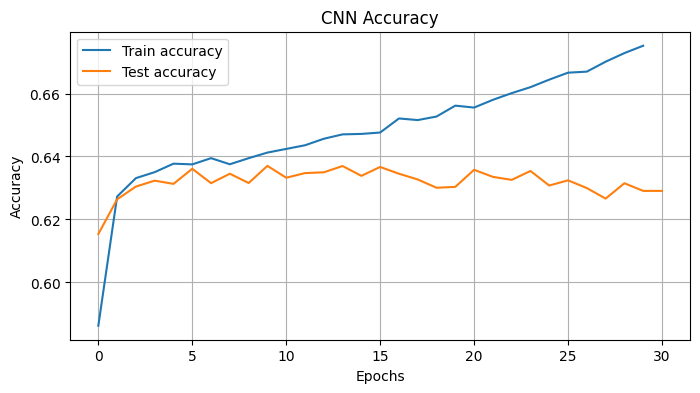

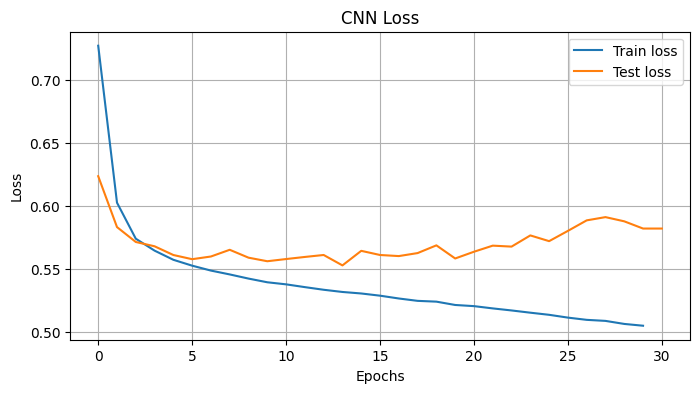

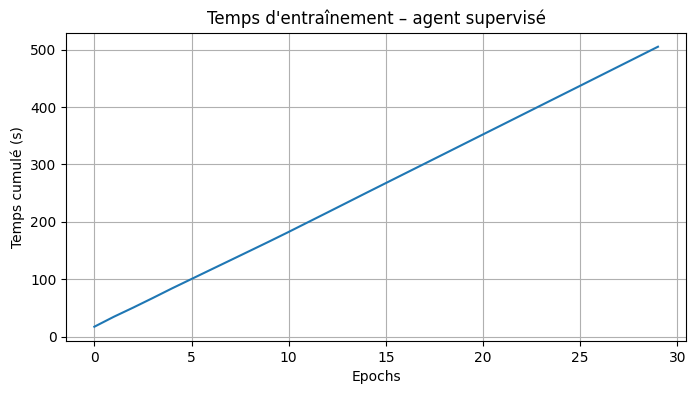

In [28]:
# Affichage des courbes CNN (accuracy, loss, temps)
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = os.path.join('results', '03')

# Accuracy
train_acc = np.load(os.path.join(base_path, 'cnn_train_accuracies.npy'))
test_acc = np.load(os.path.join(base_path, 'cnn_test_accuracies.npy'))
plt.figure(figsize=(8,4))
plt.plot(train_acc, label='Train accuracy')
plt.plot(test_acc, label='Test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
train_loss = np.load(os.path.join(base_path, 'cnn_train_losses.npy'))
test_loss = np.load(os.path.join(base_path, 'cnn_test_losses.npy'))
plt.figure(figsize=(8,4))
plt.plot(train_loss, label='Train loss')
plt.plot(test_loss, label='Test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.grid(True)
plt.show()

# Temps d'entraînement cumulé
epoch_times = np.load(os.path.join(base_path, 'cnn_epoch_times.npy'))
plt.figure(figsize=(8,4))
plt.plot(np.cumsum(epoch_times))
plt.xlabel('Epochs')
plt.ylabel('Temps cumulé (s)')
plt.title("Temps d'entraînement – agent supervisé")
plt.grid(True)
plt.show()

## 7. Expériences DQNClassifier sur la classification

Entraînement du DQNClassifier sur le jeu de données, affichage des courbes de reward, d'accuracy et de loss, analyse des performances et de la régularisation.

In [7]:
# Exécution du script d'entraînement DQNClassifier (affiche les logs comme dans le terminal)
!python trainDQNClassifier.py

INFO:root:Device utilisé : mps
INFO:root:Episode 1/10 | Train acc: 0.3628 | Test acc: 0.5190
INFO:root:Episode 2/10 | Train acc: 0.4868 | Test acc: 0.5265
INFO:root:Episode 3/10 | Train acc: 0.5333 | Test acc: 0.5343
INFO:root:Episode 4/10 | Train acc: 0.5609 | Test acc: 0.5340
INFO:root:Episode 5/10 | Train acc: 0.5670 | Test acc: 0.5343
INFO:root:Episode 6/10 | Train acc: 0.5761 | Test acc: 0.5390
INFO:root:Episode 7/10 | Train acc: 0.5779 | Test acc: 0.5393
INFO:root:Episode 8/10 | Train acc: 0.5767 | Test acc: 0.5337
INFO:root:Episode 9/10 | Train acc: 0.5711 | Test acc: 0.5393
INFO:root:Episode 10/10 | Train acc: 0.5716 | Test acc: 0.5343
INFO:root:Modèle DQNClassifier sauvegardé dans 'dqn_classifier_model.pth'


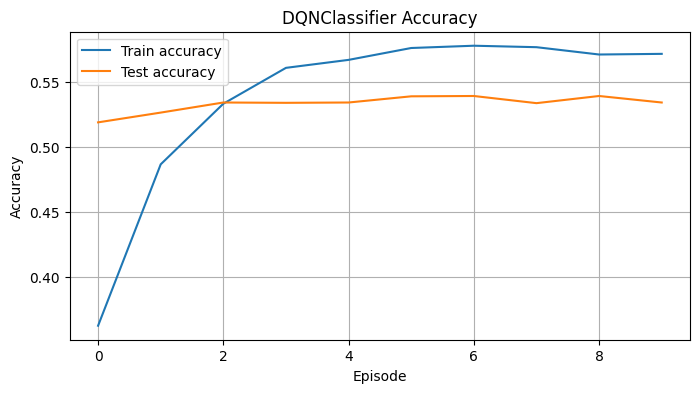

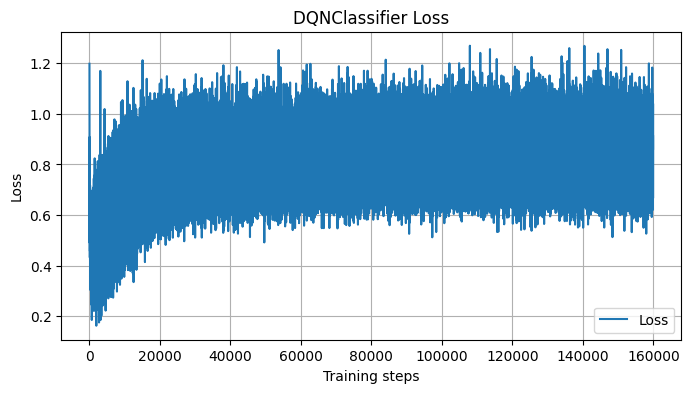

In [29]:
# Affichage des courbes DQNClassifier (accuracy, test accuracy, loss)
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = os.path.join('results', '03')

# Accuracy
train_acc = np.load(os.path.join(base_path, 'dqnclassifier_train_accuracies.npy'))
test_acc = np.load(os.path.join(base_path, 'dqnclassifier_test_accuracies.npy'))
plt.figure(figsize=(8,4))
plt.plot(train_acc, label='Train accuracy')
plt.plot(test_acc, label='Test accuracy')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.title('DQNClassifier Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
losses = np.load(os.path.join(base_path, 'dqnclassifier_losses.npy'))
plt.figure(figsize=(8,4))
plt.plot(losses, label='Loss')
plt.xlabel('Training steps')
plt.ylabel('Loss')
plt.title('DQNClassifier Loss')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
# Exécution du script d'entraînement du Qiteration (affiche les logs comme dans le terminal)
!python trainQiteration.py

INFO:root:Utilisation du GPU MPS (Apple Silicon)
INFO:root:Episode 10, Reward: -8.20, Epsilon: 0.999, Success Rate: 0.100, Loss: 0.0070, Steps: 16
INFO:root:Episode 20, Reward: -11.90, Epsilon: 0.998, Success Rate: 0.100, Loss: 0.0151, Steps: 29
INFO:root:Episode 30, Reward: -4.95, Epsilon: 0.997, Success Rate: 0.067, Loss: 0.0093, Steps: 12
INFO:root:Episode 40, Reward: -4.80, Epsilon: 0.996, Success Rate: 0.100, Loss: 0.0102, Steps: 13
INFO:root:Episode 50, Reward: -15.35, Epsilon: 0.995, Success Rate: 0.120, Loss: 0.0093, Steps: 32
INFO:root:Episode 60, Reward: -41.90, Epsilon: 0.994, Success Rate: 0.133, Loss: 0.0086, Steps: 81
INFO:root:Episode 70, Reward: -13.55, Epsilon: 0.993, Success Rate: 0.114, Loss: 0.0084, Steps: 27
INFO:root:Episode 80, Reward: -8.05, Epsilon: 0.992, Success Rate: 0.125, Loss: 0.0499, Steps: 16
INFO:root:Episode 90, Reward: -72.60, Epsilon: 0.991, Success Rate: 0.144, Loss: 0.0532, Steps: 200
INFO:root:Episode 100, Reward: -6.90, Epsilon: 0.990, Success R

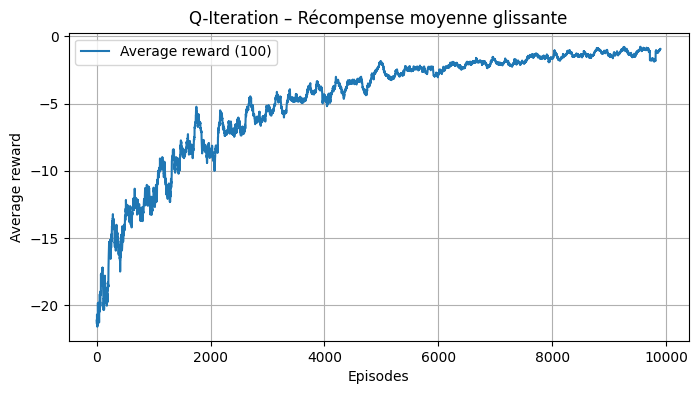

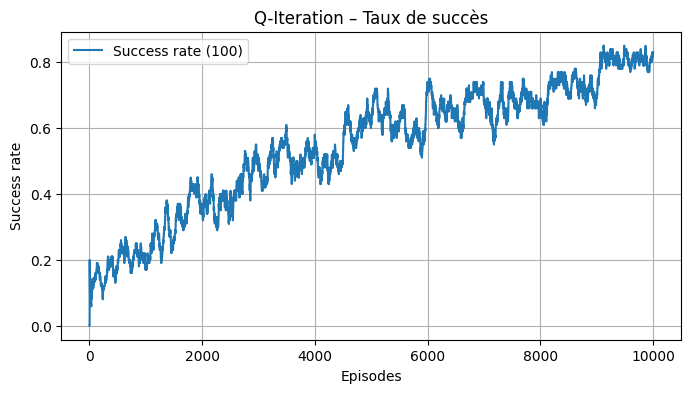

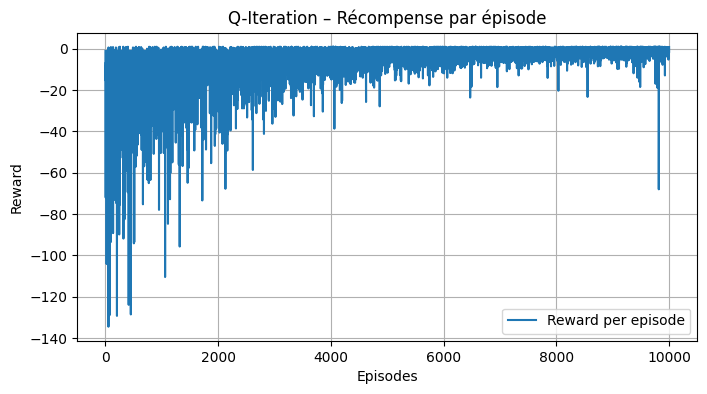

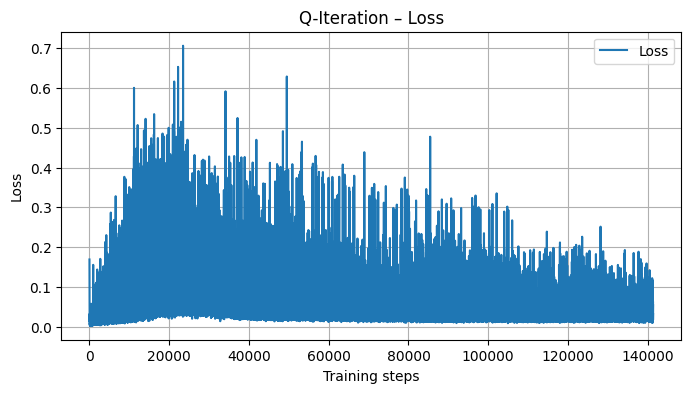

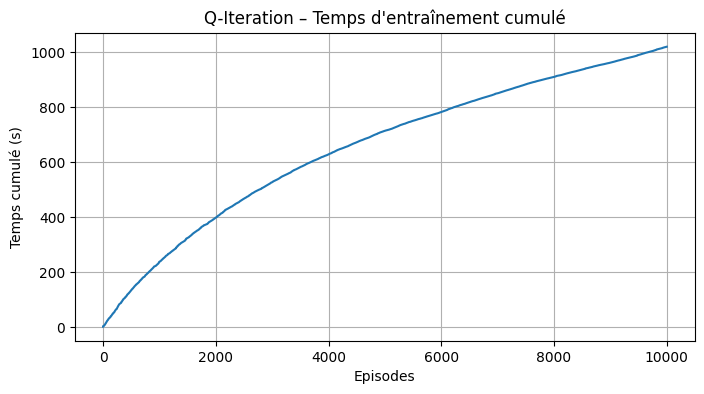

In [2]:
# Affichage des courbes Q-Iteration (avg reward, success, reward, loss, temps)
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = os.path.join('results', '03')

# Average reward (glissante)
q_avg_rewards = np.load(os.path.join(base_path, 'qiteration_avg_rewards.npy'))
plt.figure(figsize=(8,4))
plt.plot(q_avg_rewards, label='Average reward (100)')
plt.xlabel('Episodes')
plt.ylabel('Average reward')
plt.title('Q-Iteration – Récompense moyenne glissante')
plt.legend()
plt.grid(True)
plt.show()

# Success rate
q_success_rates = np.load(os.path.join(base_path, 'qiteration_success_rates.npy'))
plt.figure(figsize=(8,4))
plt.plot(q_success_rates, label='Success rate (100)')
plt.xlabel('Episodes')
plt.ylabel('Success rate')
plt.title('Q-Iteration – Taux de succès')
plt.legend()
plt.grid(True)
plt.show()

# Reward par épisode
q_rewards = np.load(os.path.join(base_path, 'qiteration_episode_rewards.npy'))
plt.figure(figsize=(8,4))
plt.plot(q_rewards, label='Reward per episode')
plt.xlabel('Episodes')
plt.ylabel('Reward')
plt.title('Q-Iteration – Récompense par épisode')
plt.legend()
plt.grid(True)
plt.show()

# Loss
q_losses = np.load(os.path.join(base_path, 'qiteration_losses.npy'))
plt.figure(figsize=(8,4))
plt.plot(q_losses, label='Loss')
plt.xlabel('Training steps')
plt.ylabel('Loss')
plt.title('Q-Iteration – Loss')
plt.legend()
plt.grid(True)
plt.show()

# Temps d'entraînement cumulé
q_training_times = np.load(os.path.join(base_path, 'qiteration_training_times.npy'))
plt.figure(figsize=(8,4))
plt.plot(q_training_times)
plt.xlabel('Episodes')
plt.ylabel('Temps cumulé (s)')
plt.title("Q-Iteration – Temps d'entraînement cumulé")
plt.grid(True)
plt.show()

In [3]:
!python testDQNClassifier.py

## 11. Conclusion et perspectives

Ce projet a permis de comparer différentes approches d'apprentissage sur des tâches variées, d'améliorer la robustesse et la reproductibilité des expériences, et de mettre en place une méthodologie rigoureuse pour l'analyse des résultats.

**Perspectives :**
- Tester d'autres architectures RL (A2C, PPO)
- Étendre à d'autres types de données
- Automatiser davantage la génération de rapports et de visualisations

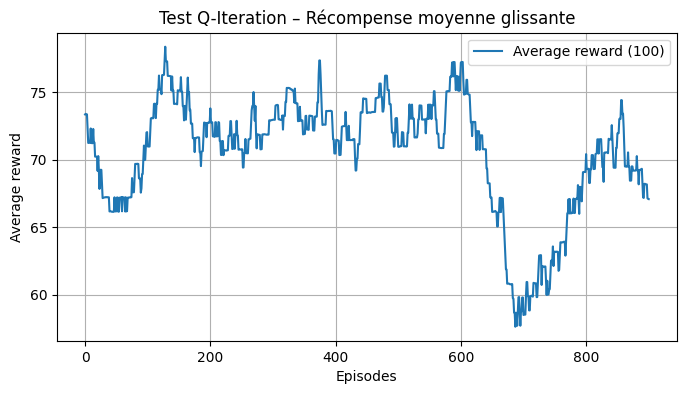

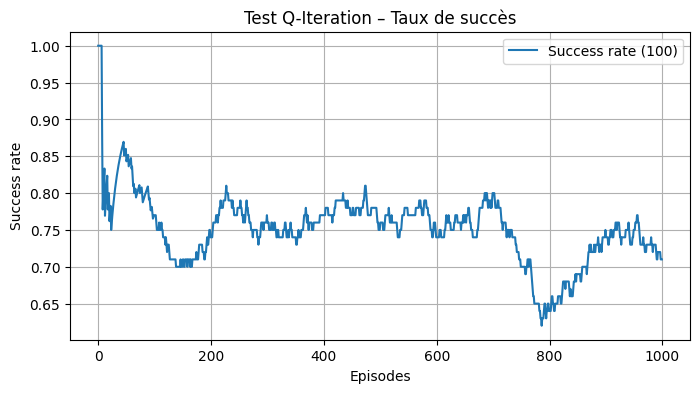

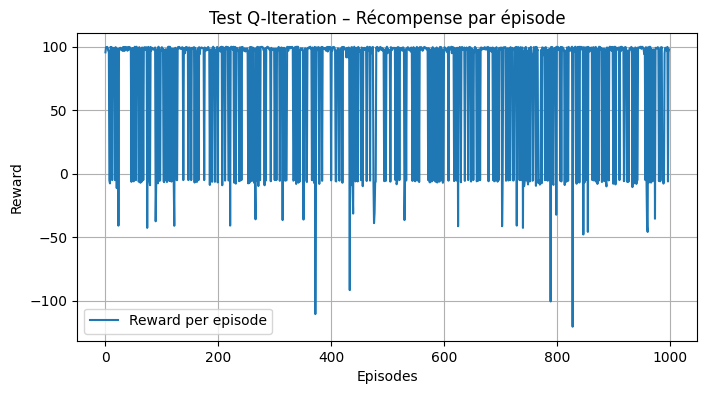

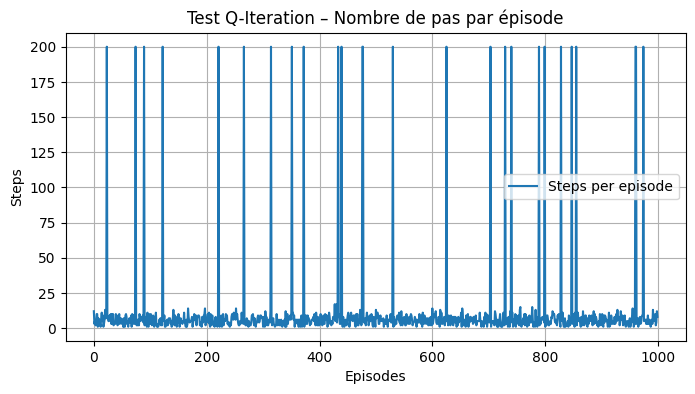

In [4]:
# Affichage des courbes de test Q-Iteration (avg reward, success, reward, steps)
import numpy as np
import matplotlib.pyplot as plt
import os

base_path = os.path.join('results', '03')

# Average reward (glissante)
test_avg_rewards = np.load(os.path.join(base_path, 'testqiteration_avg_rewards.npy'))
plt.figure(figsize=(8,4))
plt.plot(test_avg_rewards, label='Average reward (100)')
plt.xlabel('Episodes')
plt.ylabel('Average reward')
plt.title('Test Q-Iteration – Récompense moyenne glissante')
plt.legend()
plt.grid(True)
plt.show()

# Success rate
test_success_rates = np.load(os.path.join(base_path, 'testqiteration_success_rates.npy'))
plt.figure(figsize=(8,4))
plt.plot(test_success_rates, label='Success rate (100)')
plt.xlabel('Episodes')
plt.ylabel('Success rate')
plt.title('Test Q-Iteration – Taux de succès')
plt.legend()
plt.grid(True)
plt.show()

# Reward par épisode
test_rewards = np.load(os.path.join(base_path, 'testqiteration_episode_rewards.npy'))
plt.figure(figsize=(8,4))
plt.plot(test_rewards, label='Reward per episode')
plt.xlabel('Episodes')
plt.ylabel('Reward')
plt.title('Test Q-Iteration – Récompense par épisode')
plt.legend()
plt.grid(True)
plt.show()

# Steps per episode
test_steps = np.load(os.path.join(base_path, 'testqiteration_steps_per_episode.npy'))
plt.figure(figsize=(8,4))
plt.plot(test_steps, label='Steps per episode')
plt.xlabel('Episodes')
plt.ylabel('Steps')
plt.title('Test Q-Iteration – Nombre de pas par épisode')
plt.legend()
plt.grid(True)
plt.show()